<a href="https://colab.research.google.com/github/yogasgm/prototype_finetuning_pytorch/blob/main/Prototype_Multilabel_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


# Importing libraries

In [25]:
!pip install transformers

import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import random
import shutil
import sys
from sklearn.model_selection import train_test_split

In [26]:
import pandas as pd
df = pd.read_excel('/content/updated_predicted_dataset_stage1.xlsx')

# Assuming 'df' from previous cells is your data:
train_df = df.copy()  # Create a copy of 'df' and name it 'train_df'

# Convert 'Social' and 'Aesthetic' columns to integers
train_df['Social'] = train_df['Social'].fillna(0).astype(int)
train_df['Aesthetic'] = train_df['Aesthetic'].fillna(0).astype(int)

In [27]:
# Assuming your CSV file is named 'All Data_labeled.csv'
file_path = '/content/updated_predicted_dataset_stage1.xlsx'  # Assign the path to a variable
train_df = pd.read_excel(file_path) # Use the variable in pd.read_csv

# Convert 'Social' and 'Aesthetic' columns to integers
train_df['Social'] = train_df['Social'].fillna(0).astype(int)
train_df['Aesthetic'] = train_df['Aesthetic'].fillna(0).astype(int)

# Setting seed for reproducibility

In [28]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [29]:
set_seed(43)

# Downloading dataset

In [30]:
# Load the dataset directly from the Colab file system
file_path = '/content/updated_predicted_dataset_stage1.xlsx'  # Adjust the filename as needed
train_df = pd.read_excel(file_path)

# Convert 'Social' and 'Aesthetic' columns to integers
train_df['Social'] = train_df['Social'].fillna(0).astype(int)
train_df['Aesthetic'] = train_df['Aesthetic'].fillna(0).astype(int)

In [31]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20161 entries, 0 to 20160
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   clean_text     20161 non-null  object
 1   Social         20161 non-null  int64 
 2   Environmental  20161 non-null  int64 
 3   Economic       20161 non-null  int64 
 4   Cultural       20161 non-null  int64 
 5   Aesthetic      20161 non-null  int64 
dtypes: int64(5), object(1)
memory usage: 945.2+ KB


In [32]:
train_df.columns

Index(['clean_text', 'Social', 'Environmental', 'Economic', 'Cultural',
       'Aesthetic'],
      dtype='object')

# Selecting required columns

In [33]:
train_df = train_df[['clean_text', 'Social', 'Environmental', 'Economic', 'Cultural', 'Aesthetic']]

# Convert 'Social' and 'Aesthetic' columns to integers
train_df['Social'] = train_df['Social'].fillna(0).astype(int)
train_df['Aesthetic'] = train_df['Aesthetic'].fillna(0).astype(int)

In [34]:
target_list = ['Social', 'Environmental', 'Economic', 'Cultural', 'Aesthetic']

# Preparing the tokenizer

In [35]:
#Set Max Lenght, maksimal 512 (BERT)
MAX_LEN = 512

In [36]:
from transformers import BertTokenizer, BertModel

In [37]:
#download the tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

In [38]:
class CustomDataset(torch.utils.data.Dataset):

    def __init__(self, df, tokenizer, max_len):
        self.tokenizer = tokenizer
        self.df = df
        self.title = df['clean_text']
        self.targets = self.df[target_list].values
        self.max_len = max_len

    def __len__(self):
        return len(self.title)

    def __getitem__(self, index):
        title = str(self.title[index])
        title = " ".join(title.split())

        inputs = self.tokenizer.encode_plus(
            title,
            None,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            return_token_type_ids=True,
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'input_ids': inputs['input_ids'].flatten(),
            'attention_mask': inputs['attention_mask'].flatten(),
            'token_type_ids': inputs["token_type_ids"].flatten(),
            'targets': torch.FloatTensor(self.targets[index])
        }

# Splitting & Tokenizing Dataset

In [39]:
# Adjusting the train/validation/test split
train_df, temp_df = train_test_split(train_df, test_size=0.2, random_state=43)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=43)

# Reset the indices
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

In [40]:
# Label distribution in the training set
train_counts = train_df[target_list].sum(axis=0)
print("Label distribution in the training set:\n", train_counts)

# Label distribution in the validation set
val_counts = val_df[target_list].sum(axis=0)
print("\nLabel distribution in the validation set:\n", val_counts)

# Label distribution in the test set
test_counts = test_df[target_list].sum(axis=0)
print("\nLabel distribution in the test set:\n", test_counts)

Label distribution in the training set:
 Social           3685
Environmental    5056
Economic         5873
Cultural         2447
Aesthetic        1280
dtype: int64

Label distribution in the validation set:
 Social           483
Environmental    640
Economic         787
Cultural         305
Aesthetic        149
dtype: int64

Label distribution in the test set:
 Social           490
Environmental    629
Economic         707
Cultural         284
Aesthetic        155
dtype: int64


In [41]:
# Label distribution in the training set
train_counts_percentage = (train_df[target_list].sum(axis=0) / len(train_df)) * 100
print("Label distribution in the training set:\n", train_counts_percentage)

# Label distribution in the validation set
val_counts_percentage = (val_df[target_list].sum(axis=0) / len(val_df)) * 100
print("\nLabel distribution in the validation set:\n", val_counts_percentage)

# Label distribution in the test set
test_counts_percentage = (test_df[target_list].sum(axis=0) / len(test_df)) * 100
print("\nLabel distribution in the test set:\n", test_counts_percentage)

Label distribution in the training set:
 Social           22.848462
Environmental    31.349206
Economic         36.414931
Cultural         15.172371
Aesthetic         7.936508
dtype: float64

Label distribution in the validation set:
 Social           23.958333
Environmental    31.746032
Economic         39.037698
Cultural         15.128968
Aesthetic         7.390873
dtype: float64

Label distribution in the test set:
 Social           24.293505
Environmental    31.184928
Economic         35.052058
Cultural         14.080317
Aesthetic         7.684680
dtype: float64


In [42]:
train_df.shape

(16128, 6)

In [43]:
val_df.shape

(2016, 6)

In [44]:
val_df

,clean_text,Social,Environmental,Economic,Cultural,Aesthetic
0,happens country government care people,1,0,0,0,0
1,rt want join us amp clean aust divert unwanted...,0,1,0,0,0
2,clothing industry fault neighborhood looks lik...,0,0,0,0,0
3,jessip pairs north face winter boots got rid y...,0,1,0,0,1
4,need systems prioritize people planet conviven...,1,1,0,1,0
...,...,...,...,...,...,...
2011,people still buy fit,0,0,1,1,0
2012,seen items lots small businesses sell seen thi...,0,1,1,0,0
2013,amazing u learn,0,0,0,0,0
2014,many thrift shops expensive purchasing new become,0,1,1,0,0


In [45]:
test_df

,clean_text,Social,Environmental,Economic,Cultural,Aesthetic
0,using clothes years years old garv h mujhe apn...,0,0,0,0,1
1,wow incredible first hand investigation someon...,0,0,1,0,0
2,gettyyoung shein apologist,0,0,1,0,0
3,meanwhile push recycled bags seems people like...,0,1,0,0,0
4,things look indicate quality,0,0,0,0,1
...,...,...,...,...,...,...
2012,benefit lowest slave class citizens,0,0,0,0,0
2013,talk savile row sustainable fashion sewing bee...,0,0,1,0,0
2014,absurd account faced everywhere luckily never ...,0,0,1,0,0
2015,r u usa canada,0,0,0,0,0


In [47]:
# Create the CustomDataset for each set
train_dataset = CustomDataset(train_df, tokenizer, MAX_LEN)
valid_dataset = CustomDataset(val_df, tokenizer, MAX_LEN)
test_dataset = CustomDataset(test_df, tokenizer, MAX_LEN)

In [48]:
len(train_dataset)

16128

# Setting hyperparameters

In [50]:
TRAIN_BATCH_SIZE = 16
VALID_BATCH_SIZE = 16
EPOCHS = 5
LEARNING_RATE = 2e-5

In [51]:
# Preparing the DataLoaders
train_data_loader = torch.utils.data.DataLoader(train_dataset,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

val_data_loader = torch.utils.data.DataLoader(valid_dataset,
    batch_size=VALID_BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

In [52]:
# Checking for available device
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

In [53]:
device

device(type='cuda')

# Additional functions for loading and saving checkpoints

In [54]:
def load_ckp(checkpoint_fpath, model, optimizer):
    """
    checkpoint_path: path to save checkpoint
    model: model that we want to load checkpoint parameters into
    optimizer: optimizer we defined in previous training
    """
    # load check point
    checkpoint = torch.load(checkpoint_fpath)
    # initialize state_dict from checkpoint to model
    model.load_state_dict(checkpoint['state_dict'])
    # initialize optimizer from checkpoint to optimizer
    optimizer.load_state_dict(checkpoint['optimizer'])
    # initialize valid_loss_min from checkpoint to valid_loss_min
    valid_loss_min = checkpoint['valid_loss_min']
    # return model, optimizer, epoch value, min validation loss
    return model, optimizer, checkpoint['epoch'], valid_loss_min

def save_ckp(state, is_best, checkpoint_path, best_model_path):
    """
    state: checkpoint we want to save
    is_best: is this the best checkpoint; min validation loss
    checkpoint_path: path to save checkpoint
    best_model_path: path to save best model
    """
    f_path = checkpoint_path
    # save checkpoint data to the path given, checkpoint_path
    torch.save(state, f_path)
    # if it is a best model, min validation loss
    if is_best:
        best_fpath = best_model_path
        # copy that checkpoint file to best path given, best_model_path
        shutil.copyfile(f_path, best_fpath)

# Training the Model

Defining and Initializing the BERT Classification Model

In [55]:
class BERTClass(torch.nn.Module):
    def __init__(self):
        super(BERTClass, self).__init__()
        self.bert_model = BertModel.from_pretrained('bert-base-uncased', return_dict=True)
        self.dropout = torch.nn.Dropout(0.3)
        self.linear = torch.nn.Linear(768, 5)

    def forward(self, input_ids, attn_mask, token_type_ids):
        output = self.bert_model(
            input_ids,
            attention_mask=attn_mask,
            token_type_ids=token_type_ids
        )
        output_dropout = self.dropout(output.pooler_output)
        output = self.linear(output_dropout)
        return output

model = BERTClass()
model.to(device)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

BERTClass(
  (bert_model): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwi

Setting Up the Loss Function and Optimizer

In [56]:
def loss_fn(outputs, targets):
    return torch.nn.BCEWithLogitsLoss()(outputs, targets)

optimizer = torch.optim.AdamW(params =  model.parameters(), lr=LEARNING_RATE)

Initialization of Validation Target and Output Lists

In [57]:
val_targets=[]
val_outputs=[]

Training and Validation Loop with Early Stopping

In [58]:
def train_model(n_epochs, training_loader, validation_loader, model,
                optimizer, checkpoint_path, best_model_path, patience):

  # initialize tracker for minimum validation loss
  valid_loss_min = np.inf # Change np.Inf to np.inf
  no_improve = 0


  for epoch in range(1, n_epochs+1):
    train_loss = 0
    valid_loss = 0

    model.train()
    print('############# Epoch {}: Training Start   #############'.format(epoch))
    for batch_idx, data in enumerate(training_loader):
        #print('yyy epoch', batch_idx)
        ids = data['input_ids'].to(device, dtype = torch.long)
        mask = data['attention_mask'].to(device, dtype = torch.long)
        token_type_ids = data['token_type_ids'].to(device, dtype = torch.long)
        targets = data['targets'].to(device, dtype = torch.float)

        outputs = model(ids, mask, token_type_ids)

        optimizer.zero_grad()
        loss = loss_fn(outputs, targets)
        #if batch_idx%5000==0:
         #   print(f'Epoch: {epoch}, Training Loss:  {loss.item()}')

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        #print('before loss data in training', loss.item(), train_loss)
        train_loss = train_loss + ((1 / (batch_idx + 1)) * (loss.item() - train_loss))
        #print('after loss data in training', loss.item(), train_loss)

    print('############# Epoch {}: Training End     #############'.format(epoch))

    print('############# Epoch {}: Validation Start   #############'.format(epoch))
    ######################
    # validate the model #
    ######################

    model.eval()

    with torch.no_grad():
      for batch_idx, data in enumerate(validation_loader, 0):
            ids = data['input_ids'].to(device, dtype = torch.long)
            mask = data['attention_mask'].to(device, dtype = torch.long)
            token_type_ids = data['token_type_ids'].to(device, dtype = torch.long)
            targets = data['targets'].to(device, dtype = torch.float)
            outputs = model(ids, mask, token_type_ids)

            loss = loss_fn(outputs, targets)
            valid_loss = valid_loss + ((1 / (batch_idx + 1)) * (loss.item() - valid_loss))
            val_targets.extend(targets.cpu().detach().numpy().tolist())
            val_outputs.extend(torch.sigmoid(outputs).cpu().detach().numpy().tolist())

      print('############# Epoch {}: Validation End     #############'.format(epoch))
      # calculate average losses
      #print('before cal avg train loss', train_loss)
      train_loss = train_loss/len(training_loader)
      valid_loss = valid_loss/len(validation_loader)
      # print training/validation statistics
      print('Epoch: {} \tAvgerage Training Loss: {:.6f} \tAverage Validation Loss: {:.6f}'.format(
            epoch,
            train_loss,
            valid_loss
            ))

      # create checkpoint variable and add important data
      checkpoint = {
            'epoch': epoch + 1,
            'valid_loss_min': valid_loss,
            'state_dict': model.state_dict(),
            'optimizer': optimizer.state_dict()
      }


      ## TODO: save the model if validation loss has decreased
      if valid_loss <= valid_loss_min:
        print('Validation loss decreased ({:.6f} --> {:.6f}).  Saving model ...'.format(
              valid_loss_min,
              valid_loss
              ))
        save_ckp(checkpoint, True, checkpoint_path, best_model_path)
        valid_loss_min = valid_loss
        no_improve = 0
      else:
        no_improve += 1
        if no_improve >= patience:
          print("Early stopping due to no improvement in validation loss")
          break

  return model

In [59]:
# Save checkpoint

ckpt_path = '/content/ckpt.pth'
best_model_path = '/content/best_model.pth'

# Start Train

In [ ]:
trained_model = train_model(EPOCHS, train_data_loader, val_data_loader, model, optimizer, ckpt_path, best_model_path, patience=2)

############# Epoch 1: Training Start   #############


In [ ]:
# Load the saved checkpoint
model, optimizer, start_epoch, valid_loss_min = load_ckp(best_model_path, model, optimizer)

print(f'The validation loss of the best saved model is: {valid_loss_min}')

# Test

In [ ]:
# Process new dataset
#new_dataset = CustomDataset(new_df, tokenizer, MAX_LEN)
new_dataset = test_dataset

# Create DataLoader
new_data_loader = torch.utils.data.DataLoader(new_dataset,
    batch_size=VALID_BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

# Load the model
model, optimizer, start_epoch, valid_loss_min = load_ckp(best_model_path, model, optimizer)

# Switch model to the evaluation mode
model.eval()

new_outputs = []
new_targets = []
test_loss = 0.0

# Define loss function
loss_fn = torch.nn.BCEWithLogitsLoss()

# Pass new data through the model
with torch.no_grad():
    for batch_idx, data in enumerate(new_data_loader):
        ids = data['input_ids'].to(device, dtype = torch.long)
        mask = data['attention_mask'].to(device, dtype = torch.long)
        token_type_ids = data['token_type_ids'].to(device, dtype = torch.long)
        targets = data['targets'].to(device, dtype = torch.float)

        outputs = model(ids, mask, token_type_ids)

        # Calculate loss
        loss = loss_fn(outputs, targets)
        test_loss += loss.item() * data['input_ids'].size(0)

        new_outputs.extend(torch.sigmoid(outputs).cpu().detach().numpy().tolist())
        new_targets.extend(targets.cpu().detach().numpy().tolist())

# Average the test loss over all batches
test_loss = test_loss / len(new_data_loader.dataset)

print(f'Test Loss: {test_loss:.6f}')

In [ ]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

# Convert the outputs and targets to numpy arrays
new_outputs_np = np.array(new_outputs)
new_targets_np = np.array(new_targets)

# Threshold the outputs (This depends on your requirements, 0.5 is used as an example)
new_outputs_bin = (new_outputs_np > 0.5)

# Calculate metrics
print(classification_report(new_targets_np, new_outputs_bin))

# Calculate macro and micro metrics
precision_macro = precision_score(new_targets_np, new_outputs_bin, average='macro')
recall_macro = recall_score(new_targets_np, new_outputs_bin, average='macro')
f1_macro = f1_score(new_targets_np, new_outputs_bin, average='macro')

precision_micro = precision_score(new_targets_np, new_outputs_bin, average='micro')
recall_micro = recall_score(new_targets_np, new_outputs_bin, average='micro')
f1_micro = f1_score(new_targets_np, new_outputs_bin, average='micro')

print(f'Macro Precision: {precision_macro} Macro Recall: {recall_macro} Macro F1: {f1_macro}')
print(f'Micro Precision: {precision_micro} Micro Recall: {recall_micro} Micro F1: {f1_micro}')

In [ ]:
from sklearn.metrics import accuracy_score

# Calculate accuracy
accuracy = accuracy_score(new_targets_np, new_outputs_bin)

print(f'Accuracy: {accuracy}')

# **PREDICTION**

In [ ]:
pip install transformers torch


In [ ]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification


In [ ]:
# Replace with your actual model path and labels count
model_path = '/content/best_model.pth'  # Path to your saved checkpoint
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')  # Same tokenizer as used in training
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=5)  # Set num_labels to your class count


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
import torch

# Path to your checkpoint file
checkpoint_path = '/content/ckpt.pth'

# Try loading the checkpoint
try:
    state_dict = torch.load(checkpoint_path, map_location=torch.device('cuda'))
    print("Checkpoint loaded successfully.")
    print("Keys:", state_dict.keys())
except Exception as e:
    print(f"Failed to load the checkpoint: {e}")


Checkpoint loaded successfully.
Keys: dict_keys(['epoch', 'valid_loss_min', 'state_dict', 'optimizer'])


In [ ]:
import torch

# Load the checkpoint and inspect its contents
checkpoint_path = '/content/ckpt.pth'  # Replace with your checkpoint file path
state_dict = torch.load(checkpoint_path, map_location=torch.device('cuda'))  # Or 'cuda' if using GPU
print(state_dict.keys())


dict_keys(['epoch', 'valid_loss_min', 'state_dict', 'optimizer'])


In [ ]:
print(state_dict['state_dict'].keys())


odict_keys(['bert_model.embeddings.word_embeddings.weight', 'bert_model.embeddings.position_embeddings.weight', 'bert_model.embeddings.token_type_embeddings.weight', 'bert_model.embeddings.LayerNorm.weight', 'bert_model.embeddings.LayerNorm.bias', 'bert_model.encoder.layer.0.attention.self.query.weight', 'bert_model.encoder.layer.0.attention.self.query.bias', 'bert_model.encoder.layer.0.attention.self.key.weight', 'bert_model.encoder.layer.0.attention.self.key.bias', 'bert_model.encoder.layer.0.attention.self.value.weight', 'bert_model.encoder.layer.0.attention.self.value.bias', 'bert_model.encoder.layer.0.attention.output.dense.weight', 'bert_model.encoder.layer.0.attention.output.dense.bias', 'bert_model.encoder.layer.0.attention.output.LayerNorm.weight', 'bert_model.encoder.layer.0.attention.output.LayerNorm.bias', 'bert_model.encoder.layer.0.intermediate.dense.weight', 'bert_model.encoder.layer.0.intermediate.dense.bias', 'bert_model.encoder.layer.0.output.dense.weight', 'bert_mode

In [ ]:
import torch
from transformers import BertForSequenceClassification

# Path to your checkpoint file
checkpoint_path = '/content/ckpt.pth'

# Initialize the model
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=5)

# Load the checkpoint
state_dict = torch.load(checkpoint_path, map_location=torch.device('cuda'))  # Use 'cuda' if using GPU

# Access the nested 'state_dict'
# This assumes your checkpoint saved the model's state_dict under the key 'state_dict'
state_dict = state_dict['state_dict']

# Load the model weights directly
model.load_state_dict(state_dict, strict=False) # strict=False to ignore unexpected keys

# Set the model to evaluation mode
model.eval()

print("Model successfully loaded and ready for evaluation.")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model successfully loaded and ready for evaluation.


In [ ]:
import numpy as np
def predict_in_batches(texts, batch_size=8):
    # Initialize lists to store predictions
    all_predictions = []

    # Process texts in batches
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size]

        # Tokenize the batch
        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=512,
            return_tensors='pt'
        )

        # Move to device (GPU/CPU)
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        model.to(device)
        inputs = {k: v.to(device) for k, v in inputs.items()}

        # Make predictions
        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits
            batch_predictions = torch.sigmoid(logits)

        # Move predictions to CPU and convert to numpy
        batch_predictions = batch_predictions.cpu().numpy()
        all_predictions.extend(batch_predictions)

        # Clear GPU cache if using CUDA
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        # Optional: Add a progress indicator
        if i % (batch_size * 10) == 0:
            print(f"Processed {i}/{len(texts)} texts")

    return np.array(all_predictions)



In [ ]:
texts = [
    "easy answer inequality sustainable",
    "great video shopping used soon"
]


In [ ]:
predictions = predict_in_batches(texts, 8)


Processed 0/2 texts


In [ ]:
for i, text in enumerate(texts):
    print(f"Text: {text}")
    print(f"Predictions: {predictions[i].tolist()}")  # Convert tensor to list for easier readability


Text: easy answer inequality sustainable
Predictions: [0.49290013313293457, 0.6207922697067261, 0.3866005837917328, 0.47044283151626587, 0.5137155055999756]
Text: great video shopping used soon
Predictions: [0.4643706977367401, 0.6577205061912537, 0.4087991714477539, 0.4937170445919037, 0.5229174494743347]


In [ ]:
import pandas as pd

# Load the dataset
dataset_path = '/content/CLEAN DATA keyword 1 dan youtube.xlsx'  # Update with the path to your dataset
df = pd.read_excel(dataset_path)

# Display the first few rows of your dataset
print(df.head())

texts = df['clean_text'].tolist()

                           clean_text
0  easy answer inequality sustainable
1      great video shopping used soon
2            never long trends change
3                      yes save world
4    biggest flex never ordered shein


In [ ]:
# Use the function with your data
batch_size = 8  # Adjust this based on your available RAM
predictions = predict_in_batches(texts, batch_size=batch_size)
threshold = 0.55
binary_predictions = (predictions > threshold).astype(int)

Processed 0/20161 texts
Processed 80/20161 texts
Processed 160/20161 texts
Processed 240/20161 texts
Processed 320/20161 texts
Processed 400/20161 texts
Processed 480/20161 texts
Processed 560/20161 texts
Processed 640/20161 texts
Processed 720/20161 texts
Processed 800/20161 texts
Processed 880/20161 texts
Processed 960/20161 texts
Processed 1040/20161 texts
Processed 1120/20161 texts
Processed 1200/20161 texts
Processed 1280/20161 texts
Processed 1360/20161 texts
Processed 1440/20161 texts
Processed 1520/20161 texts
Processed 1600/20161 texts
Processed 1680/20161 texts
Processed 1760/20161 texts
Processed 1840/20161 texts
Processed 1920/20161 texts
Processed 2000/20161 texts
Processed 2080/20161 texts
Processed 2160/20161 texts
Processed 2240/20161 texts
Processed 2320/20161 texts
Processed 2400/20161 texts
Processed 2480/20161 texts
Processed 2560/20161 texts
Processed 2640/20161 texts
Processed 2720/20161 texts
Processed 2800/20161 texts
Processed 2880/20161 texts
Processed 2960/20

In [ ]:
# Convert predictions to a list of lists
df['predictions'] = [pred.tolist() for pred in predictions]


In [ ]:
# Add predictions to the dataframe and save
df['predicted_labels'] = binary_predictions.tolist()
df.to_csv('/content/predicted_dataset.csv', index=False)
print("Predictions saved to '/content/predicted_dataset.csv'")

Predictions saved to '/content/predicted_dataset.csv'


# Test with New Input Text

In [ ]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import DataLoader, Dataset
import pandas as pd


In [ ]:
model_name = "bert-base-uncased"  # Replace with your model
model = BertForSequenceClassification.from_pretrained(model_name)
tokenizer = BertTokenizer.from_pretrained(model_name)

# Load model onto GPU or CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [ ]:
class TestDataset(Dataset):
    def __init__(self, texts, tokenizer, max_len):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=True, # Include token_type_ids
            pad_to_max_length=True,
            truncation=True,
            return_attention_mask=True,
            return_tensors="pt",
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'token_type_ids': encoding['token_type_ids'].flatten(), # Include token_type_ids
        }

In [ ]:
# Load test dataset
file_path = "/content/CLEAN DATA keyword 1 dan youtube.xlsx"  # Path to your test dataset
test_data = pd.read_excel(file_path)
texts = test_data["clean_text"].tolist()  # Replace 'text' with the column name in your dataset

# Create DataLoader
MAX_LEN = 512
BATCH_SIZE = 16
test_dataset = TestDataset(texts, tokenizer, MAX_LEN)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


In [ ]:
test_texts = df['clean_text'].astype(str).tolist()


In [ ]:
# Example: Preprocessing test data
import pandas as pd

# Load your dataset
df = pd.read_excel('/content/CLEAN DATA keyword 1 dan youtube.xlsx')

# Select the text column and ensure it's in string format
texts = df['clean_text'].astype(str).tolist()  # Replace 'text_column' with the actual column name containing text

# Create DataLoader or preprocess texts directly
from torch.utils.data import DataLoader
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
MAX_LEN = 128

# Tokenize the texts
def tokenize_function(text):
    return tokenizer(text, padding='max_length', truncation=True, max_length=MAX_LEN, return_tensors='pt')

tokenized_texts = [tokenize_function(text) for text in texts]

# Create a DataLoader if needed
test_loader = DataLoader(tokenized_texts, batch_size=16)

In [ ]:
def predict(model, data_loader):
    model.eval()
    predictions = []

    with torch.no_grad():
        for batch in data_loader:
            # Move 'input_ids' and 'attention_mask' to device
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            # Provide token_type_ids if they are present in the batch
            # otherwise, create a tensor of zeros with the same shape as input_ids
            if 'token_type_ids' in batch:
                token_type_ids = batch['token_type_ids'].to(device)
            else:
                token_type_ids = torch.zeros_like(input_ids, device=device)

            # Pass 'input_ids', 'attention_mask', and 'token_type_ids' to the model
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)

            logits = outputs.logits
            probs = torch.nn.functional.softmax(logits, dim=-1)
            predicted_classes = torch.argmax(probs, dim=-1)
            predictions.extend(predicted_classes.cpu().numpy())

    return predictions

In [ ]:
def predict(model, data_loader):
    model.eval()
    predictions = []
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device) # Ensure the model is on the correct device

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            token_type_ids = batch['token_type_ids'].to(device) # Get token_type_ids

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids) # Pass token_type_ids

            logits = outputs.logits
            # Use sigmoid for multi-label classification
            probs = torch.sigmoid(logits).cpu().numpy()
            predictions.extend(probs)

    return np.array(predictions)

In [ ]:
def classify_text(model, text, tokenizer, max_len, threshold=0.5):
    # Prepare the text
    inputs = tokenizer.encode_plus(
        text,
        None,
        add_special_tokens=True,
        max_length=max_len,
        padding='max_length',
        return_token_type_ids=True,
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )

    input_ids = inputs['input_ids'].to(device)
    attention_mask = inputs['attention_mask'].to(device)
    token_type_ids = inputs["token_type_ids"].to(device)

    # Get the model outputs
    with torch.no_grad():
        outputs = model(input_ids, attention_mask, token_type_ids)

    # Convert to probabilities
    probabilities = torch.sigmoid(outputs).cpu().detach().numpy().tolist()

    # Define the class labels in the same order that the model was trained on
    class_labels = ['Resilience and Adaptive Capacity', 'Policy Integration and Governance', 'Awareness and Operational Capacity'] # Define your labels based on your training


    # Convert the probabilities to labels
    predicted_labels = [class_labels[i] for i, prob in enumerate(probabilities[0]) if prob > threshold]

    return probabilities, predicted_labels

In [ ]:
import numpy as np
def classify_text(model, text, tokenizer, max_len, threshold=0.5):
    # Prepare the text
    inputs = tokenizer.encode_plus(
        text,
        None,
        add_special_tokens=True,
        max_length=max_len,
        padding='max_length',
        return_token_type_ids=True,
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )

    input_ids = inputs['input_ids'].to(device)
    attention_mask = inputs['attention_mask'].to(device)
    token_type_ids = inputs["token_type_ids"].to(device)

    # Get the model outputs
    with torch.no_grad():
        outputs = model(input_ids, attention_mask, token_type_ids)

    # Extract logits and convert to probabilities using sigmoid
    logits = outputs.logits
    probabilities = torch.sigmoid(logits).cpu().detach().numpy().tolist()

    # Define the class labels in the same order that the model was trained on
    class_labels = ['Resilience and Adaptive Capacity', 'Policy Integration and Governance', 'Awareness and Operational Capacity'] # Define your labels based on your training


    # Convert the probabilities to labels
    predicted_labels = [class_labels[i] for i, prob in enumerate(probabilities[0]) if prob > threshold]

    return probabilities, predicted_labels

In [ ]:
def classify_text(model, text, tokenizer, max_len, threshold=0.5):
    # Prepare the text
    inputs = tokenizer.encode_plus(
        text,
        None,
        add_special_tokens=True,
        max_length=max_len,
        padding='max_length',
        return_token_type_ids=True,
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )

    input_ids = inputs['input_ids'].to(device)
    attention_mask = inputs['attention_mask'].to(device)
    token_type_ids = inputs["token_type_ids"].to(device)

    # Get the model outputs
    with torch.no_grad():
        outputs = model(input_ids, attention_mask, token_type_ids)

    # Convert to probabilities
    probabilities = torch.sigmoid(outputs).cpu().detach().numpy().tolist()

    # Define the class labels in the same order that the model was trained on
    class_labels = ['Excessive Resource Consumption', 'Waste Mismanagement', 'Plastic Pollution', 'Fossil Fuel Dependence', 'Food Waste']


    # Convert the probabilities to labels
    predicted_labels = [class_labels[i] for i, prob in enumerate(probabilities[0]) if prob > threshold]

    return probabilities, predicted_labels


# **PREDICTION**

In [ ]:
! pip install torch transformers pandas matplotlib openpyxl


In [ ]:
import torch
import pandas as pd
import numpy as np
from transformers import BertTokenizer, BertForSequenceClassification
import matplotlib.pyplot as plt

# Set the device to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [ ]:
import torch
from transformers import BertModel
import torch.nn as nn # Import nn for the linear layer

# Define device (CPU or GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define the custom BERTClass model (must match the architecture used for training)
class BERTClass(torch.nn.Module):
    def __init__(self):
        super(BERTClass, self).__init__()
        self.bert_model = BertModel.from_pretrained('bert-base-uncased', return_dict=True)
        self.dropout = torch.nn.Dropout(0.3)
        self.linear = torch.nn.Linear(768, 5) # Assuming 5 output labels

    def forward(self, input_ids, attn_mask, token_type_ids):
        output = self.bert_model(
            input_ids,
            attention_mask=attn_mask,
            token_type_ids=token_type_ids
        )
        output_dropout = self.dropout(output.pooler_output)
        output = self.linear(output_dropout)
        return output

# Initialize the model
model = BERTClass()

# Load model weights from the checkpoint
model_path = "/content/best_model.pth"  # Ensure the path and file are correct
try:
    # Load the entire checkpoint
    checkpoint = torch.load(model_path, map_location=device)
    # Load the state_dict from the checkpoint
    model.load_state_dict(checkpoint['state_dict'])
    model.to(device)
    print("Model loaded successfully!")
except Exception as e:
    print(f"Failed to load model: {e}")

Model loaded successfully!


In [ ]:
def predict(texts, model, tokenizer, batch_size=16):
    predictions = []

    # Process the data in batches
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size]

        # Tokenize the input texts
        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=128,  # Adjust based on your training setup
            return_tensors="pt"
        ).to(device)

        # Predict probabilities
        with torch.no_grad():
            # Pass inputs as positional arguments
            outputs = model(inputs['input_ids'], inputs['attention_mask'], inputs['token_type_ids'])
            logits = outputs
            probs = torch.sigmoid(logits).cpu().numpy()  # Use sigmoid for probabilities

        predictions.extend(probs)

    return np.array(predictions)

In [ ]:
# Load the unlabelled dataset
dataset_path = "/content/CLEAN DATA keyword 1 dan youtube.xlsx"  # Replace with your dataset path
df = pd.read_excel(dataset_path)
texts = df['clean_text'].tolist()  # Replace 'text' with the name of your text column


In [ ]:
# Predict on the dataset
predictions = predict(texts, model, tokenizer)


In [ ]:
# Define your labels
labels = ['Social', 'Environmental', 'Economic', 'Cultural', 'Aesthetic',]  # Replace with your labels

# Add predictions as new columns
for i, label in enumerate(labels):
    df[label] = predictions[:, i]

# Save the updated dataset
output_path = "predicted_dataset_stage1.xlsx"
df.to_excel(output_path, index=False)
print(f"Predictions saved to: {output_path}")


Predictions saved to: predicted_dataset_stage1.xlsx


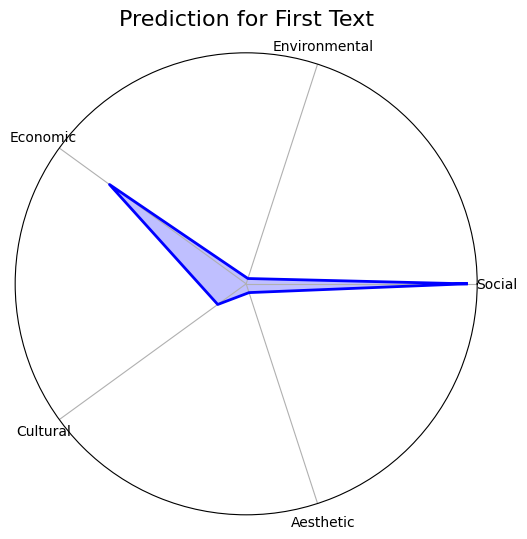

In [ ]:
def plot_spider_chart(predictions, labels, title="Prediction Visualization"):
    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
    angles += angles[:1]  # Complete the circle

    # Prepare the data for plotting
    values = predictions.tolist()
    values += values[:1]  # Complete the circle

    # Plot the spider chart
    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    ax.fill(angles, values, color='blue', alpha=0.25)
    ax.plot(angles, values, color='blue', linewidth=2)
    ax.set_yticks([])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.set_title(title, size=16, pad=20)
    plt.show()

# Visualize the first prediction
plot_spider_chart(predictions[0], labels, title="Prediction for First Text")
